<a href="https://colab.research.google.com/github/Salma5806/balance-sheet-recognition/blob/main/layoutlvm3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: SOME KAGGLE DATA SOURCES ARE PRIVATE
# RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES.
import kagglehub
kagglehub.login()


In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

salma78_layoutlvm3_datasetimg_path = kagglehub.dataset_download('salma78/layoutlvm3-datasetimg')
salma78_balance_path = kagglehub.dataset_download('salma78/balance')
salma78_rdataset_path = kagglehub.dataset_download('salma78/rdataset')
salma78_lallalala_path = kagglehub.dataset_download('salma78/lallalala')

print('Data source import complete.')


In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import json
from tqdm import tqdm

from sklearn.model_selection import train_test_split
import os
import ast
from pathlib import Path
import datasets
from PIL import Image
import pandas as pd

In [ ]:
!pip install -q git+https://github.com/huggingface/transformers.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from datasets import load_dataset

# this dataset uses the new Image feature :)
dataset = load_dataset("/kaggle/input/balance/BalanceSheetExtraction2.py")

In [ ]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'tokens', 'bboxes', 'ner_tags', 'image_path', 'image'],
        num_rows: 68
    })
    test: Dataset({
        features: ['id', 'tokens', 'bboxes', 'ner_tags', 'image_path', 'image'],
        num_rows: 17
    })
})


In [ ]:
import albumentations as A

/usr/local/lib/python3.11/dist-packages/albumentations/__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.7' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [ ]:
photometric_transform = A.Compose([
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.1, p=0.8),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=15, val_shift_limit=10, p=0.7),
    A.GaussNoise(p=0.5),  # ← ici la correction
    A.GaussianBlur(blur_limit=(3, 5), p=0.3)
])

In [ ]:
def augment_photometric(example):
    image = np.array(example['image'])  # Convertir l'image PIL en numpy array
    transformed = photometric_transform(image=image)
    example['image'] = Image.fromarray(transformed['image'])  # Retour en image PIL
    return example

In [ ]:
sample = dataset['train'][50]

In [ ]:
import numpy as np
r = augment_photometric(sample)

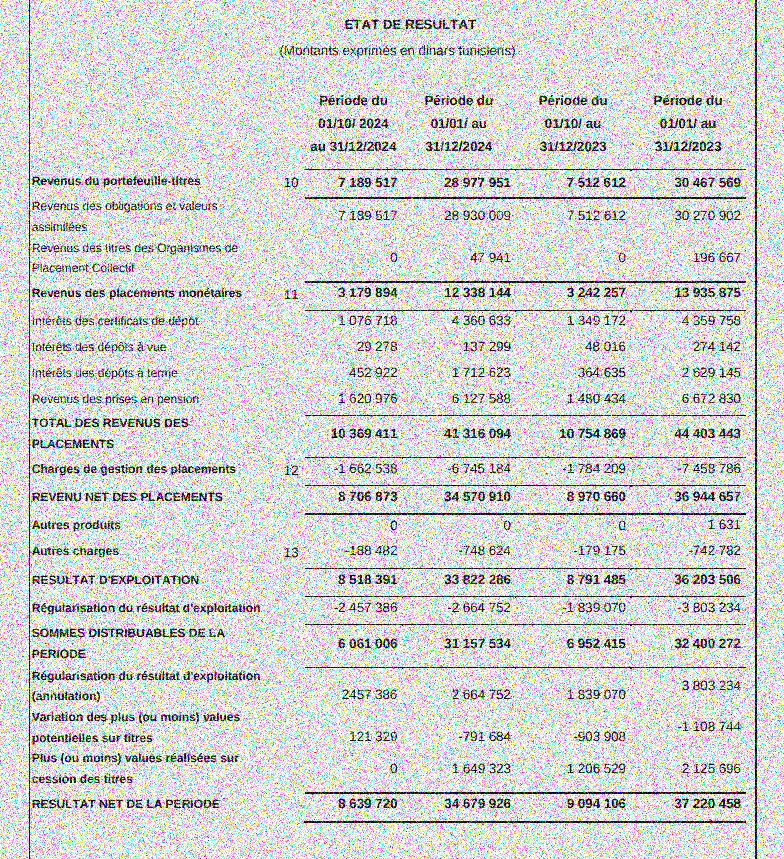

In [ ]:
r['image']

In [ ]:
augmented_dataset = dataset['train'].map(augment_photometric)

Map:   0%|          | 0/68 [00:00<?, ? examples/s]

In [ ]:
from datasets import concatenate_datasets

dataset['train'] = concatenate_datasets([dataset['train'], augmented_dataset])

In [ ]:
import numpy as np

def check_bbox_range(dataset):
    for split in ["train", "test"]:
        bboxes = dataset[split]["bboxes"]
        for i, bbox in enumerate(bboxes):
            bbox_array = np.array(bbox)
            if np.any(bbox_array < 0) or np.any(bbox_array > 1000):
                print(f"Split: {split}, Example {i}, Out-of-range bbox: {bbox_array}")
check_bbox_range(dataset)

Split: train, Example 32, Out-of-range bbox: [[  42   57  327   74]
 [  42   97  221  113]
 [ 631  135  730  150]
 [  46  176  251  191]
 [ 675  176  725  193]
 [ 789  176  840  194]
 [ 901  176  954  194]
 [  48  200  339  215]
 [ 671  199  727  216]
 [ 784  197  840  215]
 [ 896  199  954  216]
 [  45  242  293  259]
 [ 668  242  725  260]
 [ 783  241  842  259]
 [ 901  240  957  261]
 [  46  287  178  307]
 [ 709  286  728  302]
 [ 821  286  840  302]
 [ 936  286  954  302]
 [  46  308  172  326]
 [ 671  307  727  325]
 [ 786  307  839  323]
 [ 898  307  954  325]
 [  50  349  274  368]
 [ 666  352  727  368]
 [ 781  349  842  371]
 [ 901  349  957  369]
 [  46  395  378  412]
 [ 709  395  727  414]
 [ 821  395  840  414]
 [ 936  394  954  413]
 [  46  441  339  457]
 [ 671  440  727  458]
 [ 781  440  840  459]
 [ 901  440  954  458]
 [  45  485  450  501]
 [ 660  485  725  500]
 [ 789  484  840  500]
 [ 896  484  954  500]
 [  46  506  477  521]
 [ 674  505  725  522]
 [ 789  505 

In [ ]:
from PIL import Image
import numpy as np
from datasets import DatasetDict

# Fonction pour obtenir la taille d'une image
def get_image_size(image):
    # Si l'image est un objet PIL.Image
    if isinstance(image, Image.Image):
        return image.size  # Retourne (width, height)
    # Si l'image est un tableau NumPy
    elif isinstance(image, np.ndarray):
        # Supposons que le format est (height, width, channels) ou (channels, height, width)
        if len(image.shape) == 3:
            if image.shape[0] in [1, 3, 4]:  # Format (channels, height, width)
                return (image.shape[2], image.shape[1])
            else:  # Format (height, width, channels)
                return (image.shape[1], image.shape[0])
        else:
            raise ValueError(f"Format d'image non supporté : {image.shape}")
    else:
        raise ValueError(f"Type d'image non reconnu : {type(image)}")

# Fonction pour parcourir le dataset et afficher les tailles des images
def print_image_sizes(dataset: DatasetDict):
    for split in ["train", "test"]:
        print(f"\nDimensions des images dans le split '{split}':")
        for idx, example in enumerate(dataset[split]):
            image = example["image"]
            try:
                width, height = get_image_size(image)
                print(f"Exemple {idx}: width={width}, height={height}")
            except Exception as e:
                print(f"Exemple {idx}: Erreur lors de la récupération de la taille - {str(e)}")

# Exemple d'utilisation avec votre DatasetDict
# Remplacez 'dataset' par le nom de votre variable DatasetDict
print_image_sizes(dataset)


Dimensions des images dans le split 'train':
Exemple 0: width=748, height=871
Exemple 1: width=723, height=847
Exemple 2: width=717, height=871
Exemple 3: width=729, height=851
Exemple 4: width=2481, height=3509
Exemple 5: width=728, height=866
Exemple 6: width=721, height=864
Exemple 7: width=735, height=831
Exemple 8: width=588, height=857
Exemple 9: width=717, height=871
Exemple 10: width=2481, height=3509
Exemple 11: width=2482, height=3509
Exemple 12: width=2479, height=3513
Exemple 13: width=660, height=849
Exemple 14: width=2481, height=3509
Exemple 15: width=748, height=871
Exemple 16: width=717, height=871
Exemple 17: width=717, height=871
Exemple 18: width=693, height=849
Exemple 19: width=717, height=871
Exemple 20: width=797, height=862
Exemple 21: width=2481, height=3509
Exemple 22: width=2481, height=3509
Exemple 23: width=2481, height=3509
Exemple 24: width=721, height=864
Exemple 25: width=2481, height=3509
Exemple 26: width=735, height=831
Exemple 27: width=2481, heig

In [ ]:
def remove_invalid_bboxes(example):
    image_width = example['image'].size[0]
    image_height = example['image'].size[1]

    new_tokens = []
    new_bboxes = []
    new_ner_tags = []

    for token, bbox, tag in zip(example['tokens'], example['bboxes'], example['ner_tags']):
        x0, y0, x1, y1 = bbox
        if 0 <= x0 <= image_width and 0 <= y0 <= image_height and 0 <= x1 <= image_width and 0 <= y1 <= image_height:
            new_tokens.append(token)
            new_bboxes.append(bbox)
            new_ner_tags.append(tag)
        # sinon on ignore ce token (bbox invalide)

    example['tokens'] = new_tokens
    example['bboxes'] = new_bboxes
    example['ner_tags'] = new_ner_tags
    return example

dataset['train'] = dataset['train'].map(remove_invalid_bboxes)


Map:   0%|          | 0/136 [00:00<?, ? examples/s]

In [ ]:
def check_invalid_bboxes(dataset):
    for i, example in enumerate(dataset):
        for bbox in example['bboxes']:
            x0, y0, x1, y1 = bbox
            if any(coord < 0 or coord > 1000 for coord in [x0, y0, x1, y1]):
                print(f"❌ BBox invalide à l'index {i} : {bbox}")

# Appliquer sur les datasets
print("=== Vérification des bbox dans le train set ===")
check_invalid_bboxes(dataset['train'])

print("\n=== Vérification des bbox dans le test set ===")
check_invalid_bboxes(dataset['test'])


=== Vérification des bbox dans le train set ===

=== Vérification des bbox dans le test set ===


In [ ]:
sample = dataset['train'][126]

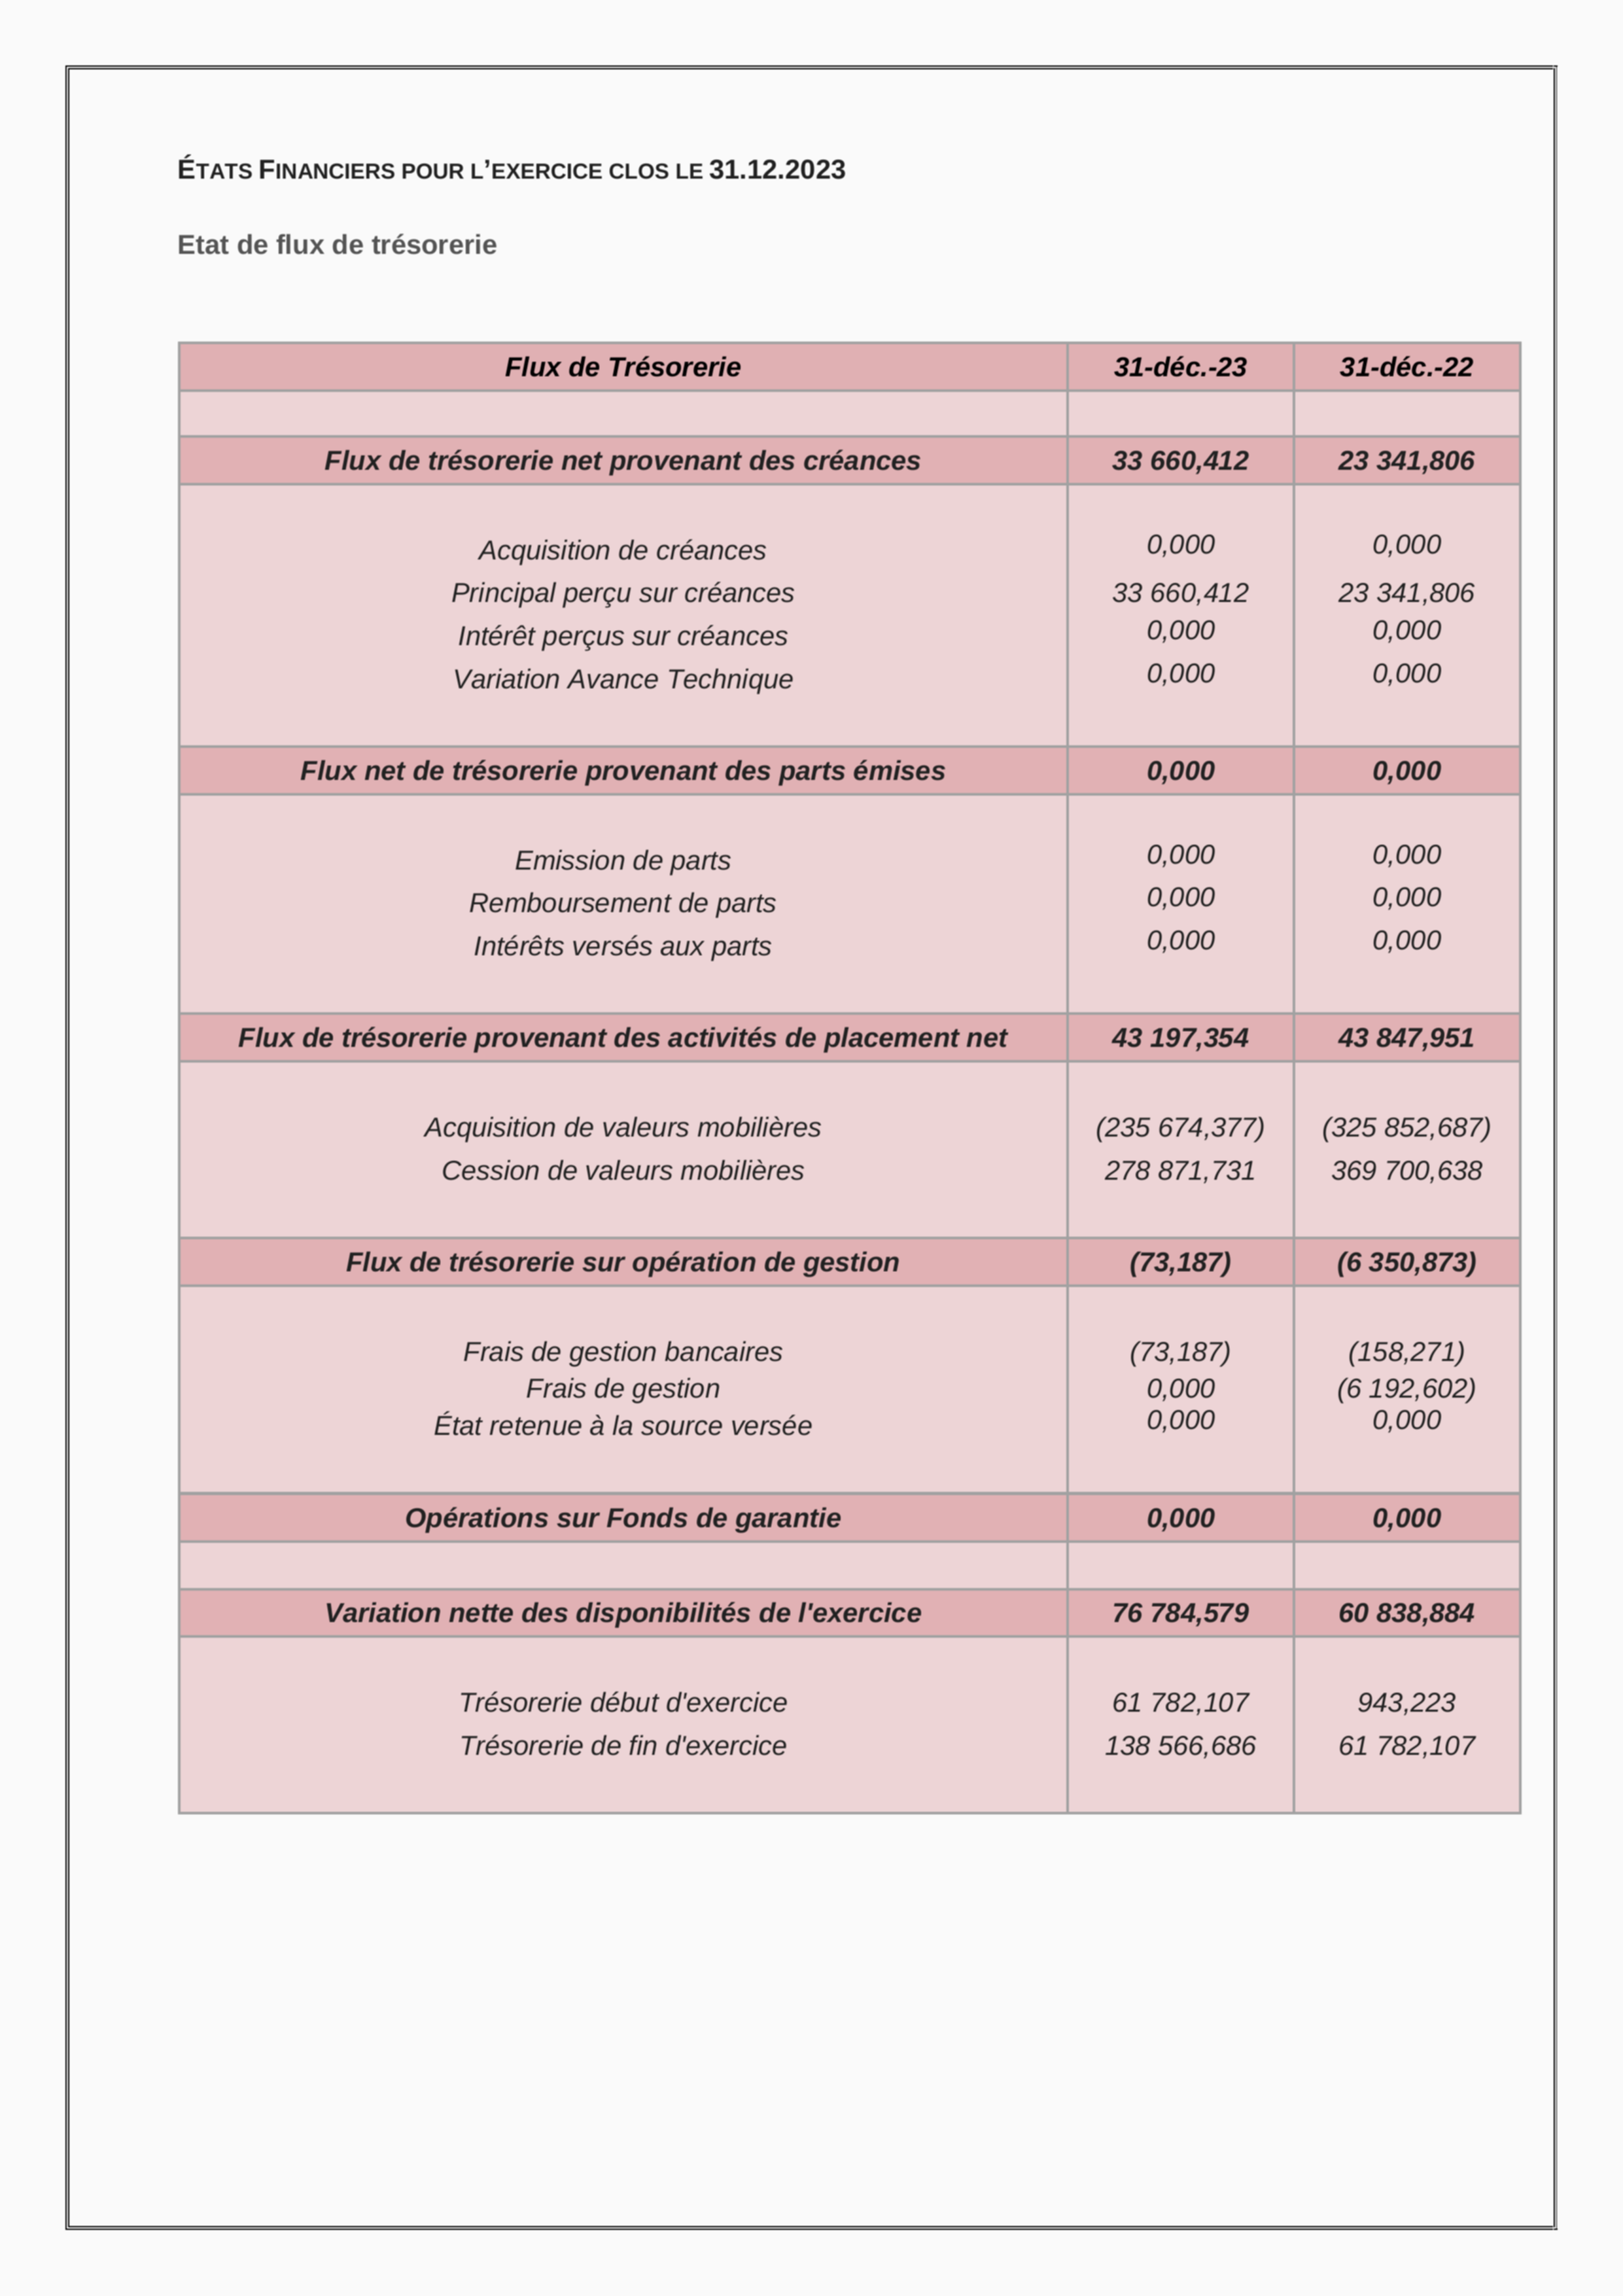

In [ ]:
sample['image']

In [ ]:
from transformers import AutoProcessor

# we'll use the Auto API here - it will load LayoutLMv3Processor behind the scenes,
# based on the checkpoint we provide from the hub
processor = AutoProcessor.from_pretrained("microsoft/layoutlmv3-base", apply_ocr=False)

2025-05-17 11:28:07.798953: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747481287.978004      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747481288.027412      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


preprocessor_config.json:   0%|          | 0.00/275 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.14k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/856 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

In [ ]:
from datasets.features import ClassLabel

features = dataset["train"].features
column_names = dataset["train"].column_names
image_column_name = "image"
text_column_name = "tokens"
boxes_column_name = "bboxes"
label_column_name = "ner_tags"

# In the event the labels are not a `Sequence[ClassLabel]`, we will need to go through the dataset to get the
# unique labels.
def get_label_list(labels):
    unique_labels = set()
    for label in labels:
        unique_labels = unique_labels | set(label)
    label_list = list(unique_labels)
    label_list.sort()
    return label_list

if isinstance(features[label_column_name].feature, ClassLabel):
    label_list = features[label_column_name].feature.names
    # No need to convert the labels since they are already ints.
    id2label = {k: v for k,v in enumerate(label_list)}
    label2id = {v: k for k,v in enumerate(label_list)}
else:
    label_list = get_label_list(dataset["train"][label_column_name])
    id2label = {k: v for k,v in enumerate(label_list)}
    label2id = {v: k for k,v in enumerate(label_list)}
num_labels = len(label_list)

In [ ]:
def prepare_examples(examples):
  images = examples[image_column_name]
  words = examples[text_column_name]
  boxes = examples[boxes_column_name]
  word_labels = examples[label_column_name]

  encoding = processor(images, words, boxes=boxes, word_labels=word_labels,
                       truncation=True, padding="max_length")

  return encoding

In [ ]:
from datasets import Features, Sequence, ClassLabel, Value, Array2D, Array3D

# we need to define custom features for `set_format` (used later on) to work properly
features = Features({
    'pixel_values': Array3D(dtype="float32", shape=(3, 224, 224)),
    'input_ids': Sequence(feature=Value(dtype='int64')),
    'attention_mask': Sequence(Value(dtype='int64')),
    'bbox': Array2D(dtype="int64", shape=(512, 4)),
    'labels': Sequence(feature=Value(dtype='int64')),
})

train_dataset = dataset["train"].map(
    prepare_examples,
    batched=True,
    remove_columns=column_names,
    features=features,
)
eval_dataset = dataset["test"].map(
    prepare_examples,
    batched=True,
    remove_columns=column_names,
    features=features,
)

Map:   0%|          | 0/136 [00:00<?, ? examples/s]

Map:   0%|          | 0/17 [00:00<?, ? examples/s]

In [ ]:
import numpy as np
from sklearn.metrics import  precision_recall_fscore_support

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # Supprimer les indices ignorés (tokens spéciaux comme -100)
    true_predictions = [
        [label_list[p] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[l] for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    # Aplatir les listes pour les métriques
    flat_predictions = [p for pred in true_predictions for p in pred]
    flat_labels = [l for label in true_labels for l in label]

    # Calculer les métriques globales
    precision, recall, f1, _ =  precision_recall_fscore_support(
        flat_labels, flat_predictions, average="weighted", labels=label_list
    )
    accuracy = (np.array(flat_predictions) == np.array(flat_labels)).mean()

    # Retourner les résultats
    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "accuracy": accuracy,
    }

In [ ]:
from transformers import LayoutLMv3ForTokenClassification

model = LayoutLMv3ForTokenClassification.from_pretrained("microsoft/layoutlmv3-base",
                                                         id2label=id2label,
                                                         label2id=label2id)

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of LayoutLMv3ForTokenClassification were not initialized from the model checkpoint at microsoft/layoutlmv3-base and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import TrainingArguments, Trainer

In [ ]:
training_args = TrainingArguments(
    output_dir="BalanceSheetExtraction",
    max_steps=500,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    learning_rate=1e-5,
    eval_strategy="steps",
    eval_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="logs",
    logging_steps=10,
    report_to= "none" ,  # Désactiver wandb
)

In [ ]:
from transformers.data.data_collator import default_data_collator
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=processor,
    data_collator=default_data_collator,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:1575: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


Step,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
100,0.039800,0.062492,0.981764,0.981023,0.980477,0.981023
200,0.050200,0.039059,0.989197,0.989274,0.989205,0.989274
300,0.031300,0.058836,0.987542,0.987624,0.987495,0.987624
400,0.006600,0.054549,0.988315,0.988449,0.988307,0.988449
500,0.008300,0.056277,0.990018,0.990099,0.990003,0.990099


/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:1575: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:1575: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:1575: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:1575: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


TrainOutput(global_step=500, training_loss=0.09541666563600301, metrics={'train_runtime': 151.2516, 'train_samples_per_second': 6.612, 'train_steps_per_second': 3.306, 'total_flos': 263600618496000.0, 'train_loss': 0.09541666563600301, 'epoch': 7.352941176470588})

In [ ]:
trainer.save_model("BalanceSheetExtraction/final_model")

In [ ]:
processor.save_pretrained("BalanceSheetExtraction/final_model")

[]

In [ ]:
trainer.evaluate()

/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:1575: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


{'eval_loss': 0.056276921182870865,
 'eval_precision': 0.9900184854805963,
 'eval_recall': 0.9900990099009901,
 'eval_f1': 0.9900028930920646,
 'eval_accuracy': 0.9900990099009901,
 'eval_runtime': 1.1328,
 'eval_samples_per_second': 15.007,
 'eval_steps_per_second': 7.945,
 'epoch': 7.352941176470588}

In [ ]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained("/kaggle/working/BalanceSheetExtraction/checkpoint-1000")


In [ ]:
print(model.config.max_position_embeddings)

514


In [ ]:
example = dataset["test"][2]
image = example["image"]
words = example["tokens"]
boxes = example["bboxes"]
word_labels = example["ner_tags"]

encoding = processor(image, words, boxes=boxes, word_labels=word_labels, return_tensors="pt")
for k,v in encoding.items():
  print(k,v.shape)

input_ids torch.Size([1, 407])
attention_mask torch.Size([1, 407])
bbox torch.Size([1, 407, 4])
labels torch.Size([1, 407])
pixel_values torch.Size([1, 3, 224, 224])


In [ ]:
import torch
def unnormalize_box(bbox, width, height):
     return [
         width * (bbox[0] / 1000),
         height * (bbox[1] / 1000),
         width * (bbox[2] / 1000),
         height * (bbox[3] / 1000),
     ]

In [ ]:
with torch.no_grad():
    outputs = model(**encoding)

logits = outputs.logits
predictions = logits.argmax(-1).squeeze().tolist()
labels = encoding.labels.squeeze().tolist()

token_boxes = encoding.bbox.squeeze().tolist()
width, height = image.size

true_predictions = [model.config.id2label[pred] for pred, label in zip(predictions, labels) if label != - 100]
true_labels = [model.config.id2label[label] for prediction, label in zip(predictions, labels) if label != -100]
true_boxes = [unnormalize_box(box, width, height) for box, label in zip(token_boxes, labels) if label != -100]


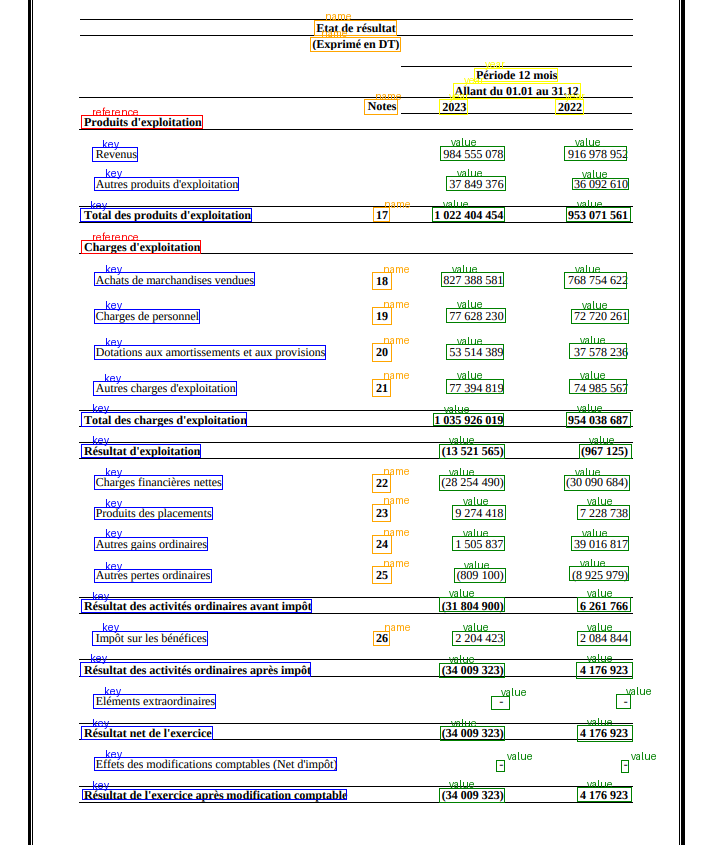

In [ ]:
from PIL import ImageDraw, ImageFont

draw = ImageDraw.Draw(image)

font = ImageFont.load_default()

def iob_to_label(label):
    label = label
    if not label:
      return 'other'
    return label

label2color = {'key':'blue', 'value':'green', 'name':'orange', 'reference': 'red', 'year': 'yellow'}

for prediction, box in zip(true_predictions, true_boxes):
    predicted_label = iob_to_label(prediction).lower()
    draw.rectangle(box, outline=label2color[predicted_label])
    draw.text((box[0] + 10, box[1] - 10), text=predicted_label, fill=label2color[predicted_label], font=font)

image

In [ ]:
!pip install paddleocr

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 45.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.8/297.8 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 86.0 MB/s eta 0:00:00:00:01
  Created wheel for fire: filename=fire-0.7.0-py3-none-any.whl size=114249 sha256=54c3acdda7b87167f654adaef07f4713cc29948507eff3bc6b149e32e076735e
  Stored in directory: /root/.cache/pip/wheels/46/54/24/1624fd5b8674eb1188623f7e8e17cdf7c0f6c24b609dfb8a89
Successfully built fire


In [ ]:
!pip install paddlepaddle

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.8/192.8 MB 9.0 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.9 MB/s eta 0:00:00
  Attempting uninstall: opt_einsum
    Found existing installation: opt_einsum 3.4.0
    Uninstalling opt_einsum-3.4.0:
      Successfully uninstalled opt_einsum-3.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.


In [ ]:
import os
from paddleocr import PaddleOCR
from PIL import Image, ImageDraw, ImageFont
import json
from uuid import uuid4
import numpy as np


# loading the engine
# OCR enginer
ocr = PaddleOCR(use_angle_cls=False,
                lang='fr',
                  rec=False,
                ) # need to run only once to download and load model into memory


/usr/local/lib/python3.11/dist-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


download https://paddleocr.bj.bcebos.com/PP-OCRv3/english/en_PP-OCRv3_det_infer.tar to /root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer/en_PP-OCRv3_det_infer.tar


100%|██████████| 3910/3910 [00:16<00:00, 235.66it/s] 


download https://paddleocr.bj.bcebos.com/PP-OCRv3/multilingual/latin_PP-OCRv3_rec_infer.tar to /root/.paddleocr/whl/rec/latin/latin_PP-OCRv3_rec_infer/latin_PP-OCRv3_rec_infer.tar


100%|██████████| 9930/9930 [00:18<00:00, 548.96it/s] 


download https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar to /root/.paddleocr/whl/cls/ch_ppocr_mobile_v2.0_cls_infer/ch_ppocr_mobile_v2.0_cls_infer.tar


100%|██████████| 2138/2138 [00:14<00:00, 146.31it/s]

[2025/05/17 11:52:55] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/latin/latin_PP-OCRv3_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_

In [ ]:
image_path = "/kaggle/input/layoutlvm3-datasetimg/15d17025-90.png"

In [ ]:
from transformers import AutoModelForTokenClassification, LayoutLMv3Processor
model = AutoModelForTokenClassification.from_pretrained("/kaggle/working/BalanceSheetExtraction/checkpoint-1000")
processor = LayoutLMv3Processor.from_pretrained("/kaggle/working/BalanceSheetExtraction/checkpoint-1000")


In [ ]:
image = Image.open("/kaggle/input/layoutlvm3-datasetimg/0451093e-126.png").convert("RGB")

In [ ]:
from paddleocr import PaddleOCR
from PIL import Image
import numpy as np
from transformers import LayoutLMv3Processor, AutoModelForTokenClassification
import torch

# Charger modèle
model_path = "BalanceSheetExtraction/final_model"
processor = LayoutLMv3Processor.from_pretrained(model_path)
model = AutoModelForTokenClassification.from_pretrained(model_path)
model.eval()

# Charger image
image_path = "/kaggle/input/layoutlvm3-datasetimg/0451093e-126.png"
image_pil = Image.open(image_path).convert("RGB")
image_np = np.array(image_pil)
image_height, image_width = image_np.shape[:2]

# OCR
ocr = PaddleOCR(use_angle_cls=False, lang='fr', rec=False)  # rec=True pour obtenir le texte
result = ocr.ocr(image_np, cls=False)

words = []
boxes = []

for item in result[0]:
    box = item[0]
    text = item[1][0]
    confidence = item[1][1]

    if text.strip() == "":
        continue

    words.append(text)

    x_min = min([pt[0] for pt in box])
    y_min = min([pt[1] for pt in box])
    x_max = max([pt[0] for pt in box])
    y_max = max([pt[1] for pt in box])

    norm_box = [
        int((x_min / image_width) * 1000),
        int((y_min / image_height) * 1000),
        int((x_max / image_width) * 1000),
        int((y_max / image_height) * 1000)
    ]
    boxes.append(norm_box)

# Encoder pour le modèle
encoding = processor(images=image_pil, text=words, boxes=boxes, return_tensors="pt", truncation=True)
with torch.no_grad():
    outputs = model(**encoding)

logits = outputs.logits
predictions = logits.argmax(-1).squeeze().tolist()
token_boxes = encoding.bbox.squeeze().tolist()

# Fonction pour dénormaliser les boîtes
def unnormalize_box(box, width, height):
    return [
        int(box[0] / 1000 * width),
        int(box[1] / 1000 * height),
        int(box[2] / 1000 * width),
        int(box[3] / 1000 * height)
    ]

# Filtrer les prédictions avec label != -100
labels = encoding.get("labels", None)
if labels is not None:
    labels = labels.squeeze().tolist()
    true_predictions = [model.config.id2label[pred] for pred, label in zip(predictions, labels) if label != -100]
    true_boxes = [unnormalize_box(box, image_width, image_height) for box, label in zip(token_boxes, labels) if label != -100]
else:
    # Si pas de labels (en test), utiliser toutes les prédictions
    true_predictions = [model.config.id2label[pred] for pred in predictions]
    true_boxes = [unnormalize_box(box, image_width, image_height) for box in token_boxes]



[2025/05/17 12:29:52] ppocr DEBUG: Namespace(help='==SUPPRESS==', use_gpu=False, use_xpu=False, use_npu=False, use_mlu=False, use_gcu=False, ir_optim=True, use_tensorrt=False, min_subgraph_size=15, precision='fp32', gpu_mem=500, gpu_id=0, image_dir=None, page_num=0, det_algorithm='DB', det_model_dir='/root/.paddleocr/whl/det/en/en_PP-OCRv3_det_infer', det_limit_side_len=960, det_limit_type='max', det_box_type='quad', det_db_thresh=0.3, det_db_box_thresh=0.6, det_db_unclip_ratio=1.5, max_batch_size=10, use_dilation=False, det_db_score_mode='fast', det_east_score_thresh=0.8, det_east_cover_thresh=0.1, det_east_nms_thresh=0.2, det_sast_score_thresh=0.5, det_sast_nms_thresh=0.2, det_pse_thresh=0, det_pse_box_thresh=0.85, det_pse_min_area=16, det_pse_scale=1, scales=[8, 16, 32], alpha=1.0, beta=1.0, fourier_degree=5, rec_algorithm='SVTR_LCNet', rec_model_dir='/root/.paddleocr/whl/rec/latin/latin_PP-OCRv3_rec_infer', rec_image_inverse=True, rec_image_shape='3, 48, 320', rec_batch_num=6, max_

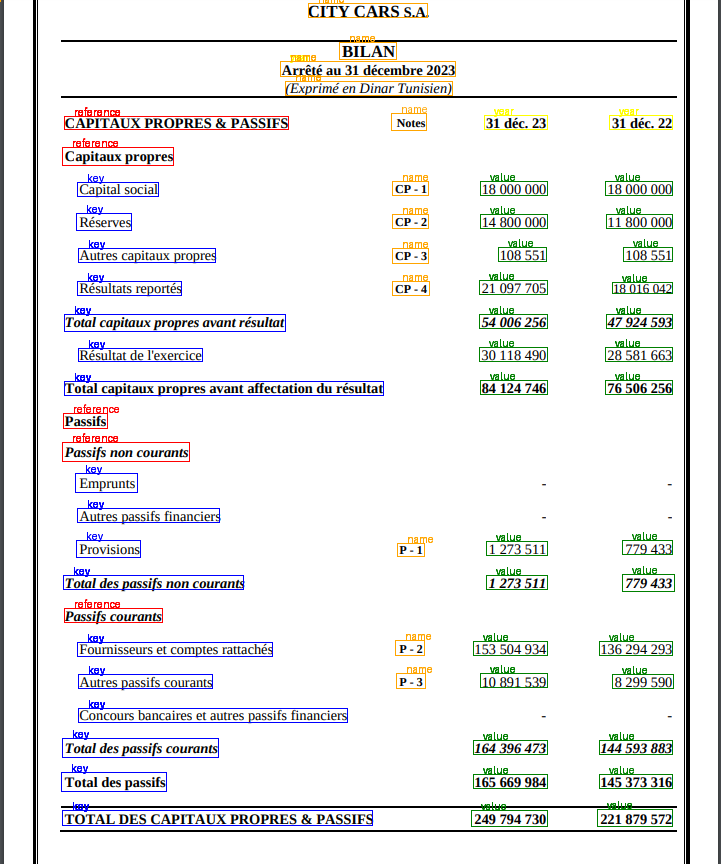

In [ ]:
from PIL import ImageDraw, ImageFont

draw = ImageDraw.Draw(image)

font = ImageFont.load_default()

def iob_to_label(label):
    label = label
    if not label:
      return 'other'
    return label

label2color = {'key':'blue', 'value':'green', 'name':'orange', 'reference': 'red', 'year': 'yellow'}


for prediction, box in zip(true_predictions, true_boxes):
    predicted_label = iob_to_label(prediction).lower()
    draw.rectangle(box, outline=label2color[predicted_label])
    draw.text((box[0] + 10, box[1] - 10), text=predicted_label, fill=label2color[predicted_label], font=font)

image

In [ ]:
import pytesseract
import pandas as pd

In [ ]:
tokens = processor.tokenizer.convert_ids_to_tokens(encoding.input_ids.squeeze())
word_ids = encoding.word_ids()

results = []

for idx, (pred, box) in enumerate(zip(predictions, token_boxes)):
    label = model.config.id2label[pred]
    if word_ids[idx] is None:
        continue

    word = words[word_ids[idx]]
    results.append({
        'text': word,
        'label': label.lower(),
        'box': unnormalize_box(box, image_width, image_height)
    })


In [ ]:
results

[{'text': 'CITY CARS S.A', 'label': 'name', 'box': [308, 3, 427, 17]},
 {'text': 'CITY CARS S.A', 'label': 'name', 'box': [308, 3, 427, 17]},
 {'text': 'CITY CARS S.A', 'label': 'name', 'box': [308, 3, 427, 17]},
 {'text': 'CITY CARS S.A', 'label': 'name', 'box': [308, 3, 427, 17]},
 {'text': 'CITY CARS S.A', 'label': 'name', 'box': [308, 3, 427, 17]},
 {'text': 'CITY CARS S.A', 'label': 'name', 'box': [308, 3, 427, 17]},
 {'text': 'BILAN', 'label': 'name', 'box': [339, 42, 396, 59]},
 {'text': 'BILAN', 'label': 'name', 'box': [339, 42, 396, 59]},
 {'text': 'BILAN', 'label': 'name', 'box': [339, 42, 396, 59]},
 {'text': 'Arreté au 31 décembre 2023',
  'label': 'name',
  'box': [280, 61, 455, 76]},
 {'text': 'Arreté au 31 décembre 2023',
  'label': 'name',
  'box': [280, 61, 455, 76]},
 {'text': 'Arreté au 31 décembre 2023',
  'label': 'name',
  'box': [280, 61, 455, 76]},
 {'text': 'Arreté au 31 décembre 2023',
  'label': 'name',
  'box': [280, 61, 455, 76]},
 {'text': 'Arreté au 31 dé

In [ ]:
unique_results = []
seen = set()
for item in results:
    key = (item['text'], item['label'], tuple(item['box']))
    if key not in seen:
        seen.add(key)
        unique_results.append(item)


In [ ]:
unique_results

[{'text': 'CITY CARS S.A', 'label': 'name', 'box': [308, 3, 427, 17]},
 {'text': 'BILAN', 'label': 'name', 'box': [339, 42, 396, 59]},
 {'text': 'Arreté au 31 décembre 2023',
  'label': 'name',
  'box': [280, 61, 455, 76]},
 {'text': 'Arreté au 31 décembre 2023',
  'label': 'year',
  'box': [280, 61, 455, 76]},
 {'text': '(Exprimé en Dinar Tunisien)',
  'label': 'name',
  'box': [285, 81, 452, 95]},
 {'text': 'CAPITAUX PROPRES & PASSIFS',
  'label': 'reference',
  'box': [64, 116, 288, 129]},
 {'text': 'Notes', 'label': 'name', 'box': [391, 113, 426, 130]},
 {'text': '31 déc. 23', 'label': 'year', 'box': [484, 115, 547, 129]},
 {'text': '31 déc. 22', 'label': 'year', 'box': [609, 115, 672, 129]},
 {'text': 'Capitaux propres',
  'label': 'reference',
  'box': [62, 147, 173, 165]},
 {'text': 'Capital social', 'label': 'key', 'box': [77, 182, 158, 196]},
 {'text': 'CP-1', 'label': 'name', 'box': [392, 181, 428, 195]},
 {'text': '18 000 000', 'label': 'value', 'box': [480, 181, 547, 195]},

In [ ]:
name_items = [item for item in unique_results if item['label'] == 'name']
year_items = [item for item in unique_results if item['label'] == 'year']
reference_items = [item for item in unique_results if item['label'] == 'reference']
key_items = [item for item in unique_results if item['label'] == 'key']
value_items = [item for item in unique_results if item['label'] == 'value']

In [ ]:
# Extraire les années
years = sorted([item['text'][-4:] for item in year_items if 'déc' in item['text']], reverse=True)  # ['2023', '2022']

# Associer les "key" aux "value" en fonction de leur position (y_min proche et x_max aligné)
data = []
for key_item in key_items:
    key_text = key_item['text']
    key_box = key_item['box']
    key_y_min = key_box[1]

    # Trouver les notes associées (si présentes)
    note = ''
    for name_item in name_items:
        if 'CP-' in name_item['text'] or 'p-' in name_item['text']:
            name_y_min = name_item['box'][1]
            if abs(name_y_min - key_y_min) < 10:  # Seuil pour alignement vertical
                note = name_item['text']
                break

    # Trouver les valeurs alignées pour 2023 et 2022
    value_2023 = None
    value_2022 = None
    for value_item in value_items:
        value_box = value_item['box']
        value_y_min = value_box[1]
        if abs(value_y_min - key_y_min) < 10:  # Seuil pour alignement vertical
            # Vérifier si la valeur est sous la colonne 2023 ou 2022
            if abs(value_box[0] - 480) < 50:  # Colonne 2023 (approximativement x=480)
                value_2023 = int(value_item['text'].replace(' ', ''))
            elif abs(value_box[0] - 605) < 50:  # Colonne 2022 (approximativement x=605)
                value_2022 = int(value_item['text'].replace(' ', ''))

    data.append({
        'key': key_text,
        'Notes': note,
        '2023': value_2023 if value_2023 is not None else 0,
        '2022': value_2022 if value_2022 is not None else 0
    })

# Créer un DataFrame
df = pd.DataFrame(data)

In [ ]:
df

,key,Notes,2023,2022
0,Capital social,CP-1,18000000,18000000
1,Réserves,CP-2,14800000,11800000
2,Autres capitaux propres,CP-3,108551,108551
3,Résultats reportés,CP-4,21097705,18016042
4,Total capitaux propres avant résultat,,54006256,47924593
5,Resultat de I'exercice,,30118490,28581663
6,Total capitaux propres avant affectation du ré...,,84124746,76506256
7,Emprunts,,0,0
8,Autres passifs financiers,,0,0
9,Provisions,p-1,1273511,779433
